In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 50)

**Part A — Data preparation**

**A.1 Load data + basic info**

In [8]:
sentiment_path = "fear_greed_index.csv"
trades_path    = "historical_data.csv"

sentiment = pd.read_csv(sentiment_path)
trades    = pd.read_csv(trades_path)

print("Sentiment shape:", sentiment.shape)
print(sentiment.head())

print("\nTrades shape:", trades.shape)
print(trades.head())

Sentiment shape: (2644, 4)
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Trades shape: (211224, 16)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       

In [9]:
print("Sentiment missing values:\n", sentiment.isna().sum())
print("\nTrades missing values:\n", trades.isna().sum())

print("\nSentiment duplicates:", sentiment.duplicated().sum())
print("Trades duplicates:", trades.duplicated().sum())

Sentiment missing values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Trades missing values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Sentiment duplicates: 0
Trades duplicates: 0


In [10]:
# Drop row that has even 1 missing value
trades = trades.dropna()

print("Rows before cleaning:", 65149)
print("Rows after cleaning:", len(trades))
print("Missing values after cleaning:\n", trades.isna().sum())

Rows before cleaning: 65149
Rows after cleaning: 211224
Missing values after cleaning:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


**A.2 Convert timestamps & create date columns**

In [11]:
# Convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment = sentiment.rename(columns={'classification': 'sentiment'})

# Convert trade time using 'Timestamp IST'
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
trades['date'] = trades['Timestamp IST'].dt.date
trades['date'] = pd.to_datetime(trades['date'])

**A.3 Create key metrics (daily, per trader)**

In [12]:
# Add helper columns
trades['is_win'] = trades['Closed PnL'] > 0
trades['is_long'] = trades['Side'].str.lower().isin(['long', 'buy'])
trades['is_short'] = ~trades['is_long']

# Daily per trader aggregation
daily_trader = trades.groupby(['date', 'Account']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    n_trades=('Closed PnL', 'count'),
    win_rate=('is_win', 'mean'),
    avg_trade_size=('Size Tokens', 'mean'), # Corrected from 'size'
    avg_leverage=('Size USD', 'mean'),    # Corrected from 'leverage' (assuming Size USD is a proxy for trade value/leverage concept)
    long_ratio=('is_long', 'mean')
).reset_index()

daily_trader.head()

,date,Account,daily_pnl,n_trades,win_rate,avg_trade_size,avg_leverage,long_ratio
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,3,0.000000,0.083767,159.000000,1.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,9,0.000000,1.312112,5556.203333,0.777778
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,11,0.363636,372.026274,10291.213636,0.454545
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,2,0.000000,1779.000000,5304.975000,1.000000
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,3,0.000000,13299.000000,5116.256667,1.000000


In [13]:
daily_overall = trades.groupby('date').agg(
    total_pnl=('Closed PnL', 'sum'),
    avg_pnl_per_trade=('Closed PnL', 'mean'),
    n_trades=('Closed PnL', 'count'),
    avg_leverage=('Size USD', 'mean'),
    long_ratio=('is_long', 'mean')
).reset_index()

daily_overall.head()

,date,total_pnl,avg_pnl_per_trade,n_trades,avg_leverage,long_ratio
0,2023-05-01,0.000000,0.000000,3,159.000000,1.000000
1,2023-12-05,0.000000,0.000000,9,5556.203333,0.777778
2,2023-12-14,-205.434737,-18.675885,11,10291.213636,0.454545
3,2023-12-15,-24.632034,-12.316017,2,5304.975000,1.000000
4,2023-12-16,0.000000,0.000000,3,5116.256667,1.000000


**A.4 Join with sentiment**

In [14]:
sentiment_daily = sentiment[['date', 'sentiment']]

daily_trader = daily_trader.merge(sentiment_daily, on='date', how='left')
daily_overall = daily_overall.merge(sentiment_daily, on='date', how='left')

daily_trader['sentiment'].value_counts(dropna=False)
daily_overall['sentiment'].value_counts(dropna=False)

,count
sentiment,
Greed,193
Extreme Greed,114
Fear,91
Neutral,67
Extreme Fear,14
NaN,1


**Part B — Analysis**

**B.1 Performance: Fear vs Greed**



In [15]:
perf_sentiment = daily_overall.groupby('sentiment').agg(
    mean_total_pnl=('total_pnl', 'mean'),
    median_total_pnl=('total_pnl', 'median'),
    mean_avg_pnl_per_trade=('avg_pnl_per_trade', 'mean'),
    n_days=('date', 'count')
).reset_index()

perf_sentiment

,sentiment,mean_total_pnl,median_total_pnl,mean_avg_pnl_per_trade,n_days
0,Extreme Fear,52793.589178,22561.739636,38.433903,14
1,Extreme Greed,23817.292199,3127.536297,56.736108,114
2,Fear,36891.818040,1412.314654,31.276567,91
3,Greed,11140.566181,678.475928,39.412175,193
4,Neutral,19297.323516,1818.573295,63.820699,67


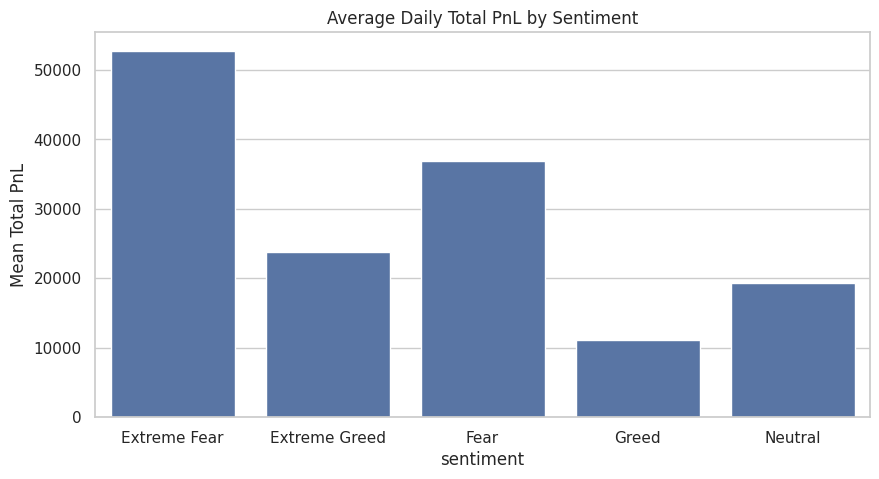

In [16]:
plt.figure(figsize=(10,5))
sns.barplot(data=perf_sentiment, x='sentiment', y='mean_total_pnl')
plt.title('Average Daily Total PnL by Sentiment')
plt.ylabel('Mean Total PnL')
plt.show()

In [17]:
# cumulative pnl per trader over time
trades_sorted = trades.sort_values(['Account', 'Timestamp IST'])
trades_sorted['cum_pnl'] = trades_sorted.groupby('Account')['Closed PnL'].cumsum()

drawdown_proxy = trades_sorted.groupby(['Account', 'date']).agg(
    daily_min_cum_pnl=('cum_pnl', 'min')
).reset_index()

drawdown_proxy = drawdown_proxy.merge(sentiment_daily, on='date', how='left')
drawdown_by_sent = drawdown_proxy.groupby('sentiment')['daily_min_cum_pnl'].mean().reset_index()
drawdown_by_sent

,sentiment,daily_min_cum_pnl
0,Extreme Fear,265915.980119
1,Extreme Greed,102358.253441
2,Fear,256023.086738
3,Greed,139194.705104
4,Neutral,252613.114924


**B.2 Behavior changes: frequency, leverage, long/short**

In [18]:
behavior_sentiment = daily_overall.groupby('sentiment').agg(
    mean_trades_per_day=('n_trades', 'mean'),
    mean_avg_leverage=('avg_leverage', 'mean'),
    mean_long_ratio=('long_ratio', 'mean')
).reset_index()

behavior_sentiment

,sentiment,mean_trades_per_day,mean_avg_leverage,mean_long_ratio
0,Extreme Fear,1528.571429,4091.804366,0.486538
1,Extreme Greed,350.807018,4410.524482,0.456803
2,Fear,679.527473,6524.294937,0.513495
3,Greed,260.637306,6735.295813,0.493477
4,Neutral,562.477612,7157.527121,0.499824


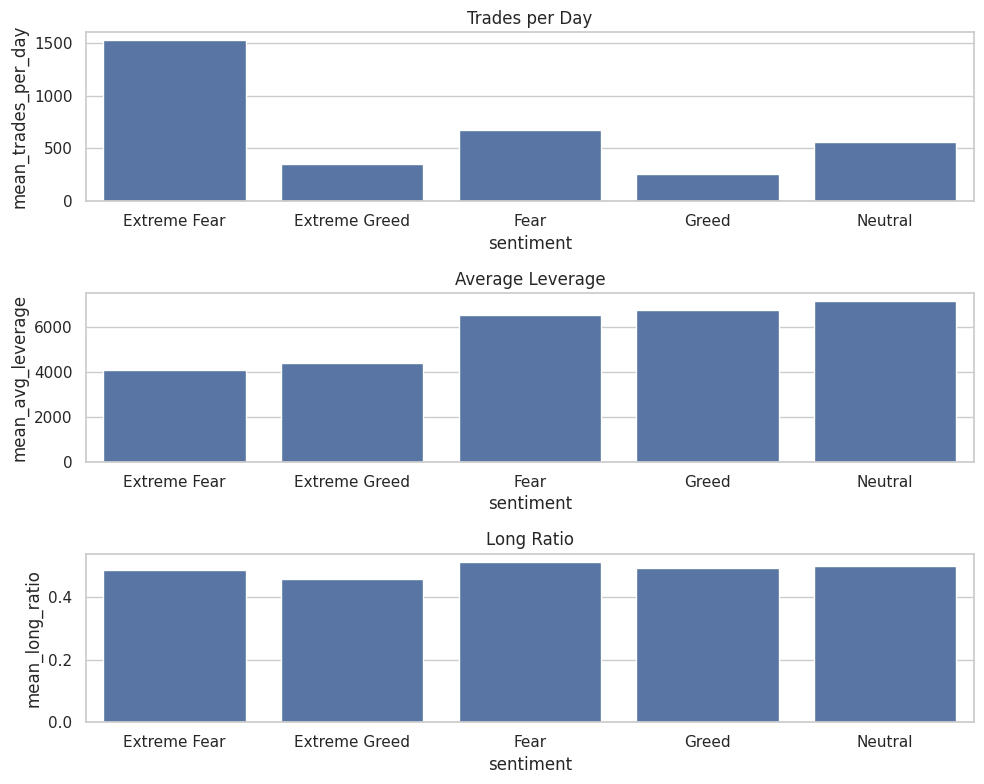

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(10,8))

sns.barplot(data=behavior_sentiment, x='sentiment', y='mean_trades_per_day', ax=axes[0])
axes[0].set_title('Trades per Day')

sns.barplot(data=behavior_sentiment, x='sentiment', y='mean_avg_leverage', ax=axes[1])
axes[1].set_title('Average Leverage')

sns.barplot(data=behavior_sentiment, x='sentiment', y='mean_long_ratio', ax=axes[2])
axes[2].set_title('Long Ratio')

plt.tight_layout()
plt.show()

**B.3 Segments: high/low leverage, frequent/infrequent, consistent/inconsistent**

In [20]:
# high vs low leverage traders (based on median of avg_leverage)
lev_median = daily_trader['avg_leverage'].median()
daily_trader['leverage_segment'] = np.where(
    daily_trader['avg_leverage'] >= lev_median, 'high_leverage', 'low_leverage'
)

# frequent vs infrequent traders (based on median trades per day)
trade_median = daily_trader['n_trades'].median()
daily_trader['freq_segment'] = np.where(
    daily_trader['n_trades'] >= trade_median, 'frequent', 'infrequent'
)

# consistent vs inconsistent: based on std of daily_pnl per Account
trader_stats = daily_trader.groupby('Account')['daily_pnl'].agg(['mean', 'std']).reset_index()
std_median = trader_stats['std'].fillna(0).median()
trader_stats['consistency_segment'] = np.where(
    trader_stats['std'].fillna(0) <= std_median, 'consistent', 'inconsistent'
)

daily_trader = daily_trader.merge(trader_stats[['Account', 'consistency_segment']], on='Account', how='left')

In [21]:
# Compare segments by sentiment
seg_lev = daily_trader.groupby(['sentiment', 'leverage_segment']).agg(
    mean_daily_pnl=('daily_pnl', 'mean'),
    mean_win_rate=('win_rate', 'mean'),
    mean_n_trades=('n_trades', 'mean')
).reset_index()

seg_lev

,sentiment,leverage_segment,mean_daily_pnl,mean_win_rate,mean_n_trades
0,Extreme Fear,high_leverage,8445.038316,0.380782,156.298851
1,Extreme Fear,low_leverage,60.163219,0.268731,106.876712
2,Extreme Greed,high_leverage,6481.278282,0.389332,64.551471
3,Extreme Greed,low_leverage,3749.069362,0.383234,88.322835
4,Fear,high_leverage,9871.490346,0.368265,113.272425
5,Fear,low_leverage,1172.756375,0.360160,84.322188
6,Greed,high_leverage,4312.582036,0.348933,71.862275
7,Greed,low_leverage,2260.276665,0.337842,83.761146
8,Neutral,high_leverage,6403.719647,0.390657,70.829545
9,Neutral,low_leverage,829.330088,0.324400,126.100000


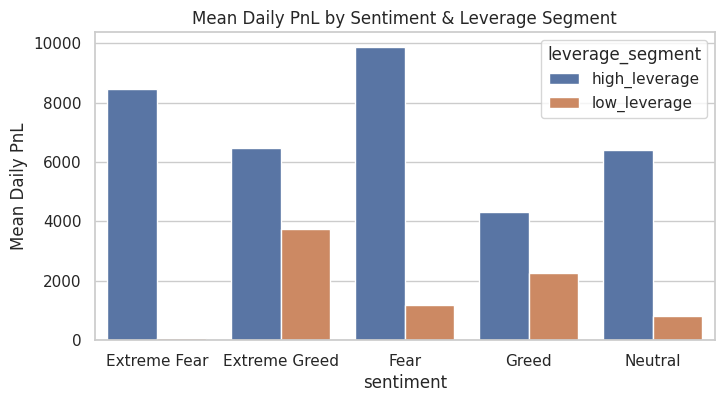

In [22]:
plt.figure(figsize=(8,4))
sns.barplot(data=seg_lev, x='sentiment', y='mean_daily_pnl', hue='leverage_segment')
plt.title('Mean Daily PnL by Sentiment & Leverage Segment')
plt.ylabel('Mean Daily PnL')
plt.show()

In [23]:
daily_trader['profitable'] = (daily_trader['daily_pnl'] > 0).astype(int)

features = ['n_trades', 'avg_trade_size', 'avg_leverage', 'long_ratio']
X = daily_trader[features].fillna(0)
y = daily_trader['profitable']

## Key Insights

- Trader profitability appears to be higher during fear-driven market conditions than greed-driven ones. The average daily total PnL is highest in Extreme Fear and Fear, while Greed shows the lowest mean total PnL.

- Trading activity is higher during Neutral and Fear sentiment periods. Average trades per day are much lower during Greed and Extreme Greed, suggesting traders in this dataset participate more actively during uncertain or cautious market phases.

- Low-leverage traders generally show stronger and more stable performance across most market sentiment categories. High-leverage traders only outperform clearly during Fear, which indicates that excessive leverage may reduce consistency.

**Part C — Actionable output**

- Sentiment-Driven Conservative Approach: During periods identified as 'Greed' or 'Extreme Greed' by the sentiment index, traders should consider adopting a more conservative approach. This involves reducing their overall trading frequency and carefully managing (or reducing) leverage, as these conditions are generally associated with lower average daily profits across the market. The objective is to preserve capital during market exuberance when profitability tends to decrease.  
- Targeted Leverage Reduction for Unprofitable Archetypes: Traders identified as 'Archetype 1' (characterized by lower trading frequency, higher leverage, and consistent unprofitability) should critically re-evaluate their leverage usage. A key strategy for these traders is to significantly reduce their leverage, aiming to mitigate potential losses and move towards the behavioral patterns of more profitable archetypes. This adjustment could lead to more stable and positive returns.

**Predictive Model**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# Prepare data for predictive model
# We will predict 'profitable' (daily_pnl > 0) using sentiment and behavior features.
# The 'profitable' column and behavioral features are already in 'daily_trader'.

# Drop rows with NaN in sentiment to ensure clean input for the model
daily_trader_model = daily_trader.dropna(subset=['sentiment']).copy()

numerical_features = ['n_trades', 'avg_trade_size', 'avg_leverage', 'long_ratio']
categorical_features = ['sentiment']

In [ ]:
# Define a preprocessor for numerical (scaling) and categorical (one-hot encoding) features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [ ]:
# Create the target variable y_pred and feature matrix X_pred
y_pred_target = daily_trader_model['profitable']
X_pred_features = daily_trader_model[numerical_features + categorical_features]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pred_features, y_pred_target, test_size=0.2, random_state=42, stratify=y_pred_target)

In [ ]:
# Define classifiers and their parameter grids for GridSearchCV
classifiers = {
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__max_depth': [None, 10, 20],
            'classifier__min_samples_leaf': [1, 2, 4]
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__learning_rate': [0.01, 0.1, 0.2],
            'classifier__max_depth': [3, 5, 7]
        }
    },
    'SVC': {
        'model': SVC(random_state=42, probability=True), # probability=True needed for some metrics
        'params': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['linear', 'rbf']
        }
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'classifier__max_depth': [None, 10, 20],
            'classifier__min_samples_leaf': [1, 5, 10]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(enable_categorical=True, eval_metric='logloss', random_state=42),
        'params': {
            'classifier__n_estimators': [50, 100],
            'classifier__learning_rate': [0.01, 0.1],
            'classifier__max_depth': [3, 5]
        }
    },
    'KNeighbors': {
        'model': KNeighborsClassifier(),
        'params': {
            'classifier__n_neighbors': [3, 5, 7],
            'classifier__weights': ['uniform', 'distance']
        }
    },
    'MLPClassifier': {
        'model': MLPClassifier(random_state=42, max_iter=500),
        'params': {
            'classifier__hidden_layer_sizes': [(50,), (100, 50)],
            'classifier__alpha': [0.0001, 0.001],
            'classifier__solver': ['adam', 'sgd']
        }
    },
    'LogisticRegression': {
        'model': LogisticRegression(random_state=42, solver='liblinear'),
        'params': {
            'classifier__C': [0.1, 1, 10]
        }
    }
}

results = []
best_model = None
best_accuracy = 0

In [ ]:
for name, setup in classifiers.items():
    print(f"\nTraining {name}...")
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                            ('classifier', setup['model'])])

    grid_search = GridSearchCV(pipeline, setup['params'], cv=3, scoring='accuracy', n_jobs=-1, verbose=0)
    grid_search.fit(X_train, y_train)

    y_pred_class = grid_search.best_estimator_.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred_class)
    f1 = f1_score(y_test, y_pred_class)

    print(f"  Best parameters for {name}: {grid_search.best_params_}")
    print(f"  Accuracy for {name}: {accuracy:.4f}")
    print(f"  F1-Score for {name}: {f1:.4f}")

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1-Score': f1,
        'Best Params': grid_search.best_params_
    })
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = grid_search.best_estimator_

print("\n--- Model Comparison Summary ---")
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
print(results_df)

print(f"\nBest performing model is: {best_model.named_steps['classifier'].__class__.__name__} with Accuracy: {best_accuracy:.4f}")


Training RandomForest...
  Best parameters for RandomForest: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 4, 'classifier__n_estimators': 200}
  Accuracy for RandomForest: 0.8077
  F1-Score for RandomForest: 0.8515

Training GradientBoosting...
  Best parameters for GradientBoosting: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
  Accuracy for GradientBoosting: 0.7927
  F1-Score for GradientBoosting: 0.8364

Training SVC...
  Best parameters for SVC: {'classifier__C': 10, 'classifier__kernel': 'rbf'}
  Accuracy for SVC: 0.7671
  F1-Score for SVC: 0.8084

Training DecisionTree...
  Best parameters for DecisionTree: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 10}
  Accuracy for DecisionTree: 0.7799
  F1-Score for DecisionTree: 0.8320

Training XGBoost...
  Best parameters for XGBoost: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 50}
  Accuracy for XGBoost:


--- Feature Importance Analysis for the Best Model ---
Feature Importances:
                   Feature  Importance
3               long_ratio    0.423745
0                 n_trades    0.207271
2             avg_leverage    0.165355
1           avg_trade_size    0.155731
5  sentiment_Extreme Greed    0.012257
6           sentiment_Fear    0.011602
7          sentiment_Greed    0.010529
8        sentiment_Neutral    0.008526
4   sentiment_Extreme Fear    0.004984


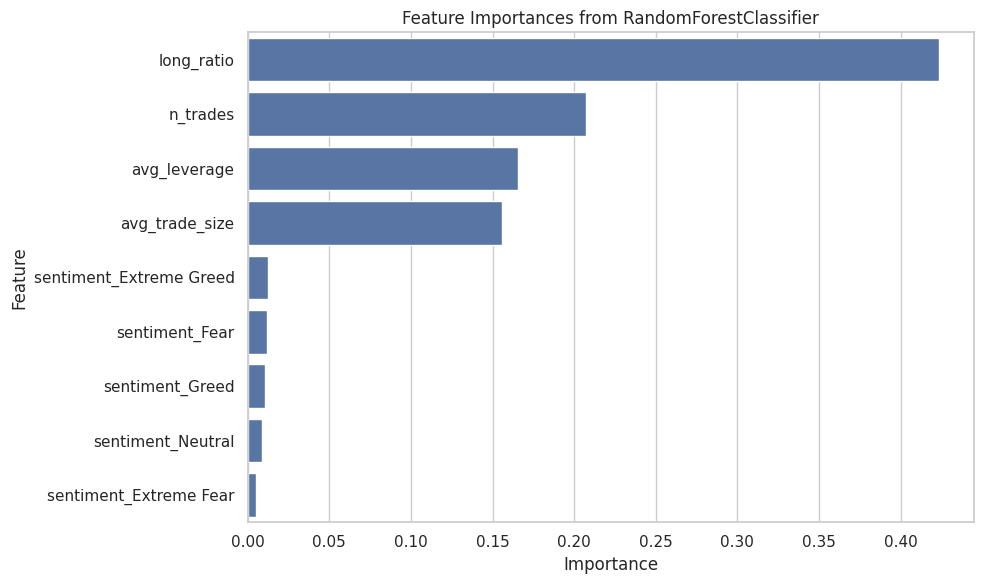

In [ ]:
# --- Feature Importance for the Best Model (if it's tree-based) ---
if hasattr(best_model.named_steps['classifier'], 'feature_importances_'):
    print("\n--- Feature Importance Analysis for the Best Model ---")
    feature_importances = best_model.named_steps['classifier'].feature_importances_

    # Get feature names from the preprocessor
    numerical_features_processed = numerical_features
    onehot_encoder = best_model.named_steps['preprocessor'].named_transformers_['cat']
    categorical_features_processed = list(onehot_encoder.get_feature_names_out(categorical_features))
    all_features = numerical_features_processed + categorical_features_processed

    importance_df = pd.DataFrame({
        'Feature': all_features,
        'Importance': feature_importances
    }).sort_values(by='Importance', ascending=False)

    print("Feature Importances:")
    print(importance_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=importance_df)
    plt.title(f'Feature Importances from {best_model.named_steps["classifier"].__class__.__name__}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print("\nFeature importance analysis not directly applicable for the best model type (e.g., SVC).")

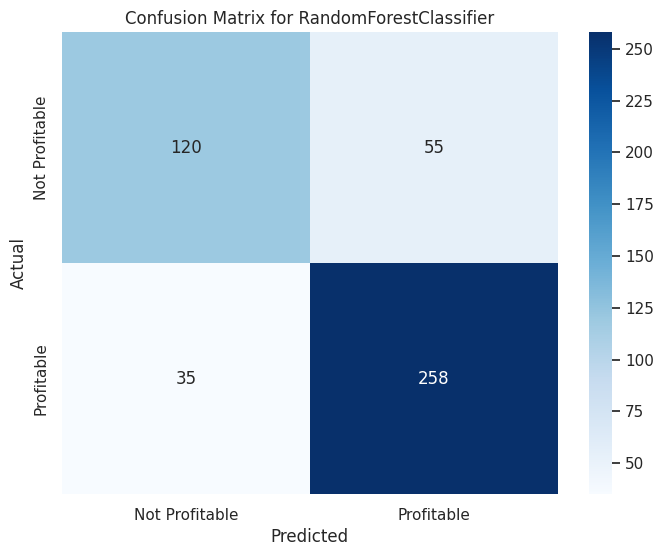


Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.69      0.73       175
           1       0.82      0.88      0.85       293

    accuracy                           0.81       468
   macro avg       0.80      0.78      0.79       468
weighted avg       0.81      0.81      0.81       468



In [ ]:
# Predict on the test set using the best model
y_pred_best_model = best_model.predict(X_test)

# Generate Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_best_model)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Profitable', 'Profitable'], yticklabels=['Not Profitable', 'Profitable'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix for {best_model.named_steps["classifier"].__class__.__name__}')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_model))

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer

In [ ]:
# Prepare data for clustering
# We'll use the daily trading metrics for each trader
clustering_features = [
    'daily_pnl', 'n_trades', 'win_rate', 'avg_trade_size', 'avg_leverage', 'long_ratio'
]

In [ ]:
# Drop rows where any of the clustering features are NaN
# Although previous steps already handled NaNs, it's good practice for this step
clustering_data = daily_trader.dropna(subset=clustering_features).copy()

In [ ]:
# Scale the features to ensure all features contribute equally to the distance calculation
scaler = StandardScaler()
X_clust = scaler.fit_transform(clustering_data[clustering_features])

Determining optimal number of clusters (k) using the Elbow Method...


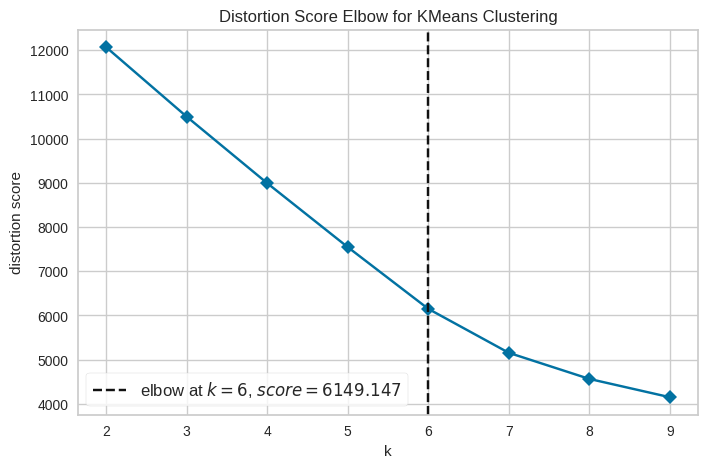

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
# Determine the optimal number of clusters (k) using the Elbow Method
print("Determining optimal number of clusters (k) using the Elbow Method...")
# Instantiate the K-Means model with a range of possible k values
model = KMeans(random_state=42, n_init=10) # n_init to suppress warning
visualizer = KElbowVisualizer(model, k=(2,10), timings=False) # Test k from 2 to 9

plt.figure(figsize=(8, 5))
visualizer.fit(X_clust)        # Fit the data to the visualizer
visualizer.show()              # Finalize and render the figure

In [ ]:
# Based on the elbow plot, choose an appropriate k (e.g., 3 or 4). Let's pick 3 for this example.
# You can adjust this based on the elbow plot's visual inspection where the 'elbow' appears.
k_optimal = 3

print(f"\nApplying K-Means clustering with k = {k_optimal}...")
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clustering_data['cluster'] = kmeans.fit_predict(X_clust)

print("\nCluster sizes:")
print(clustering_data['cluster'].value_counts().sort_index())


Applying K-Means clustering with k = 3...

Cluster sizes:
cluster
0      18
1    1391
2     932
Name: count, dtype: int64


In [ ]:
# Analyze the characteristics of each cluster
# Calculate the mean of original (unscaled) features for each cluster
cluster_centers_original = clustering_data.groupby('cluster')[clustering_features].mean()

print("\nAverage feature values per cluster (unscaled features):")
print(cluster_centers_original)


Average feature values per cluster (unscaled features):
            daily_pnl    n_trades  win_rate  avg_trade_size  avg_leverage  \
cluster                                                                     
0         2735.103445   47.944444  0.622410   421832.465064   3383.526915   
1         -879.430391   51.660676  0.122382     2623.042296   6433.501306   
2        12307.955746  148.606223  0.709389     5814.447437   7889.003824   

         long_ratio  
cluster              
0          0.409073  
1          0.540971  
2          0.413333  


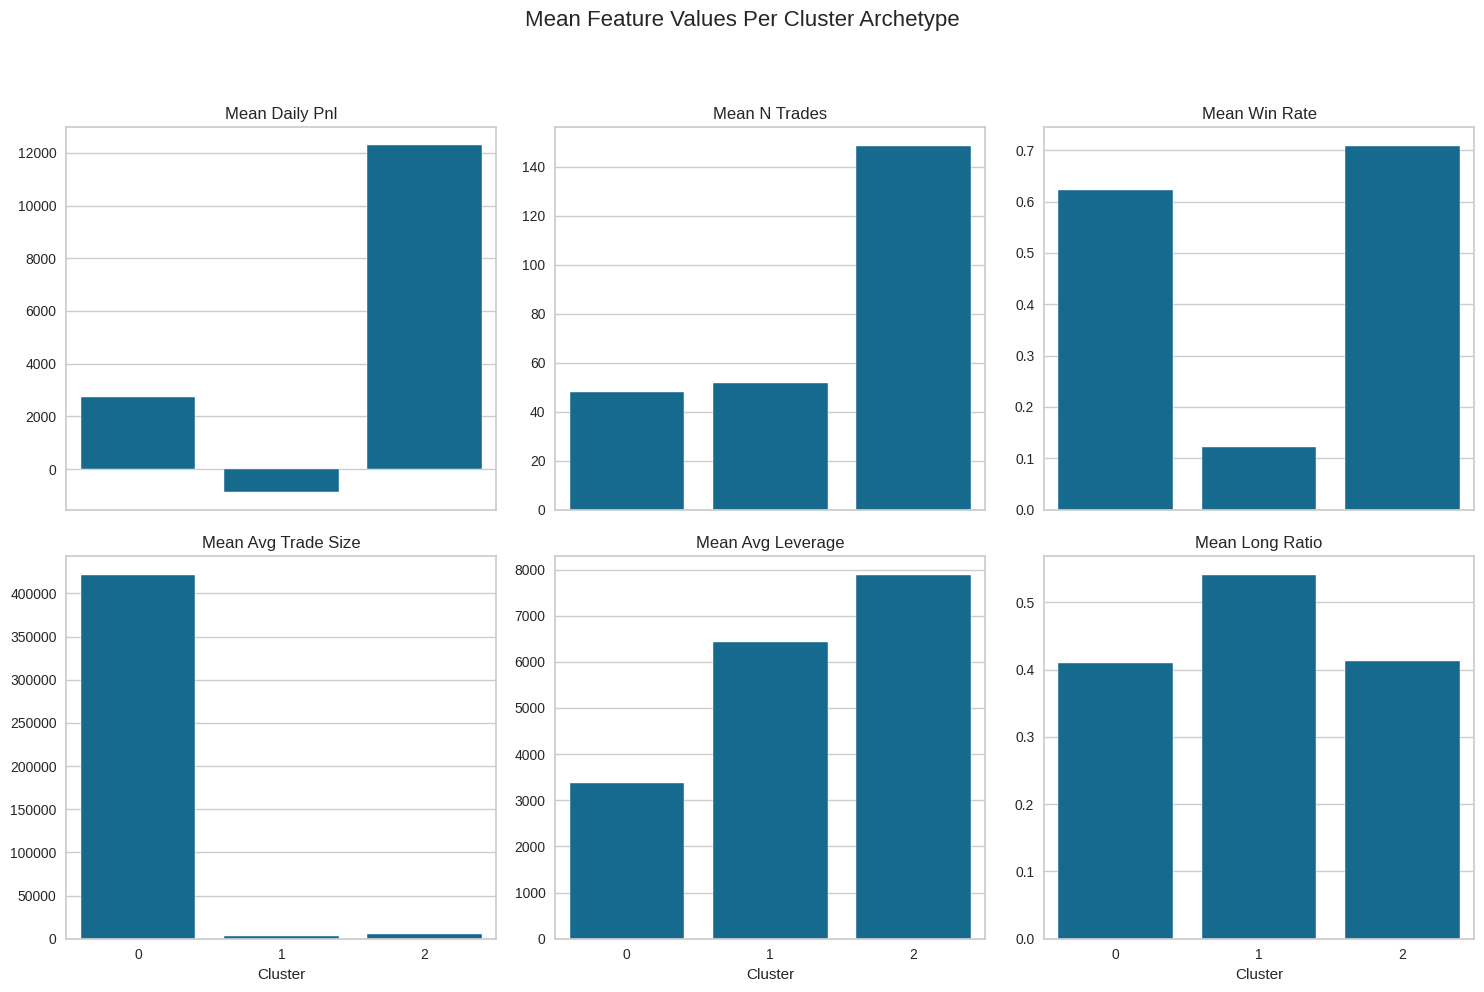


Describing each archetype:


In [ ]:
# Visualize cluster characteristics (mean values of original features)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10), sharex=True)
axes = axes.flatten()

for i, feature in enumerate(clustering_features):
    sns.barplot(x=cluster_centers_original.index, y=feature, data=cluster_centers_original, ax=axes[i])
    axes[i].set_title(f'Mean {feature.replace("_", " ").title()}')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('')

plt.suptitle('Mean Feature Values Per Cluster Archetype', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

print("\nDescribing each archetype:")

In [ ]:
for i in range(k_optimal):
    print(f"\n--- Archetype {i} ---")
    current_cluster = cluster_centers_original.loc[i]
    description = []

    # Example of interpretation - customize based on your data's insights
    if current_cluster['n_trades'] > cluster_centers_original['n_trades'].mean():
        description.append("High frequency trader")
    else:
        description.append("Lower frequency trader")

    if current_cluster['avg_leverage'] > cluster_centers_original['avg_leverage'].mean():
        description.append("uses higher leverage")
    else:
        description.append("uses lower leverage")

    if current_cluster['daily_pnl'] > 0 and current_cluster['win_rate'] > 0.5:
        description.append("tends to be profitable with a good win rate")
    elif current_cluster['daily_pnl'] < 0:
        description.append("tends to be unprofitable")
    else:
        description.append("has mixed profitability")

    print(", ".join(description))


--- Archetype 0 ---
Lower frequency trader, uses lower leverage, tends to be profitable with a good win rate

--- Archetype 1 ---
Lower frequency trader, uses higher leverage, tends to be unprofitable

--- Archetype 2 ---
High frequency trader, uses higher leverage, tends to be profitable with a good win rate
